In [1]:
import pandas as pd

In [2]:
#1
df = pd.read_csv("/content/Airplane_Crashes_and_Fatalities_Since_1908.csv")

In [3]:
#2
df.shape

(5268, 13)

In [4]:
#3
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [5]:
#4
df.isnull().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22



Date – No treatment is required because there are no missing values in this column.

Time – Missing values can be indicated Unknown because using an average time could bring inaccurate information.

Location – Missing values can be indicated Unknown because the location is important information, and assigning a location that was not recorded could make the data inaccurate.

Operator – Missing values can be indicated as Unknown because we cannot reliably determine which operator was involved when the information was not recorded.

Flight No – Missing values can be indicated Unknown. However, because a very large proportion of this column is missing, dropping the column could also be considered.

Route – Missing values can be indicated as Unknown because we cannot assume the route taken when it was not recorded.

Type – Missing values can be indicated as Unknown because the aircraft type should not be assumed when it was not recorded.

Registration – Missing values can be indicated as Unknown because the aircraft registration is an identifying detail that should not be guessed.

cn/In – Missing values can be indicated Unknown because the aircraft's serial number cannot be reliably determined when it is missing.

Aboard – The missing values can be replaced with the median because it is less affected by unusually large or small numbers of people aboard a plane.

Fatalities – The missing values can be replaced with the median because this is a numerical variable and only 12 values are missing.

Ground – Missing values can be left as missing because the actual number of people killed on the ground cannot be reliably determined

Summary – Missing values can be indicated as Unknown because we cannot create an accurate description of the crash when no summary was recorded.



In [8]:
#5
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']]

In [10]:
fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]

,2963
Date,03/27/1977
Location,"Tenerife, Canary Islands"
Aboard,644.0
Fatalities,583.0


In [11]:
#7
fatality_locations[fatality_locations['Fatalities'] == 0]

,Date,Location,Aboard,Fatalities
108,10/21/1926,English Channel,12.0,0.0
387,03/05/1936,"Near Tengya, China",6.0,0.0
889,10/08/1947,"Near El Paso, Texas",54.0,0.0
897,11/11/1947,"Gallup, New Mexico",25.0,0.0
1265,05/25/1953,"Amsterdam, Netherlands",34.0,0.0
1359,01/19/1955,"Des Moines, Iowa",39.0,0.0
1440,09/09/1956,"Bartlesville, Oklahoma",18.0,0.0
1443,10/16/1956,Over the PacifiOcean,31.0,0.0
1610,06/30/1959,"Ishikawa City, Ryukyu Island, Okinawa",1.0,0.0
1837,02/28/1963,"Boston, Massachusetts",26.0,0.0


In [13]:
#8
fatality_locations[['Region', 'State/Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)
fatality_locations.head()

/tmp/ipykernel_1061/1939778983.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fatality_locations[['Region', 'State/Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)
/tmp/ipykernel_1061/1939778983.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fatality_locations[['Region', 'State/Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)


,Date,Location,Aboard,Fatalities,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,Victoria,"British Columbia, Canada"
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


In [14]:
fatality_locations = fatality_locations.sort_values('Fatalities', ascending=False).head(100)
fatality_locations

,Date,Location,Aboard,Fatalities,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,Mt. Osutaka,"near Ueno Village, Japan"
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,Elburz Mtns.,"near Laskarak, Markazi, Iran"
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


<Axes: ylabel='count'>

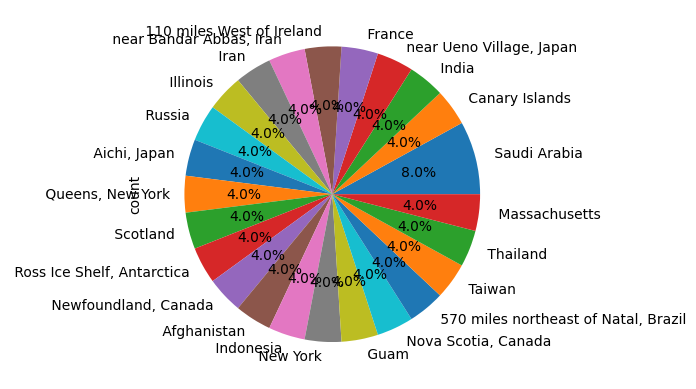

In [16]:
#10
top25['State/Country'].value_counts().plot.pie(autopct='%1.1f%%')